## Predicting MLB WAR Using FanGraphs Data

In this notebook, I build regression models to predict a specific players seasonal WAR (Wins Above Replacement) using underlying skill metrics and positional data from FanGraphs.

WAR is one of the most comprehensive metrics because it captures offense, baserunning, defense, and positional value in a single measure. That also makes it challenging to predict from offensive inputs alone.

To reduce data leakage, I excluded direct counting and outcome based stats such as home runs, RBI, OBP, SLG, and OPS. Because those metrics are already closely tied to run production and WAR, including them would inflate model performance without providing as much insight into the skills that drive player value.

Instead, this project focuses on descriptive player profile metrics that better reflect underlying talent and approach. These include:

- Plate discipline (BB%, K%)
- Quality of contact (Barrel%, HardHit%, Exit Velocity, maxEV)
- Batted ball profile (Launch Angle, GB%, LD%, Pull%, Oppo%)
- Speed / athleticism (Spd)
- Positional value

The goals of this project are to:

1. Predict seasonal WAR using measurable underlying player traits  
2. Identify which skills are most associated with high WAR  
3. Compare offensive only models against models that include position  
4. Analyze players who outperform or underperform model expectations  

### Python Imports

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


## Initial Data Preparation

The primary dataset was loaded from the `Data` folder in this repository and come from FanGraphs leaderboards.

Each row represents aseason observation for a single player from 2015 through 2025.

This time period was selected to allow for Statcast era data such as Barrel%, HardHit%, Exit Velocity, and Launch Angle.

For the baseline model, the data was cleaned and prepared by:

- Selecting relevant offensive skill metrics
- Removing unnecessary identifier columns
- Filtering out the shortened 2020 season
- Defining WAR as the target variable
- Creating training and testing datasets for modeling

Positional data was introduced later as a separate feature engineering step to evaluate how much defensive role and positional scarcity improve WAR prediction.

In [264]:
df = pd.read_csv('data/WAR Predictor 15-25.csv')

In [265]:
# removing the shortened 2020 season
df = df[df['Season'] != 2020]

Preview of the data

In [169]:
df.head()

,Season,Name,Team,PA,WAR,BB%,K%,Barrel%,HardHit%,EV,...,LD%,GB%,FB%,Pull%,Cent%,Oppo%,Spd,NameASCII,PlayerId,MLBAMID
0,2025,Oneil Cruz,PIT,544,1.580288,0.117647,0.319853,0.178808,0.566225,95.835664,...,0.145695,0.480132,0.374172,0.407285,0.384106,0.208609,7.068212,Oneil Cruz,21711,665833
1,2017,Giancarlo Stanton,MIA,692,6.434607,0.122832,0.235549,0.173913,0.457666,92.009653,...,0.160183,0.446224,0.393593,0.446224,0.352403,0.201373,2.259233,Giancarlo Stanton,4949,519317
2,2021,Giancarlo Stanton,NYY,579,3.050541,0.108808,0.271157,0.157303,0.556180,95.100852,...,0.185393,0.446629,0.367978,0.379213,0.339888,0.280899,0.603186,Giancarlo Stanton,4949,519317
3,2018,Giancarlo Stanton,NYY,705,3.772407,0.099291,0.299291,0.151442,0.507212,93.694444,...,0.185096,0.449519,0.365385,0.389423,0.370192,0.240385,3.768260,Giancarlo Stanton,4949,519317
4,2024,Oneil Cruz,PIT,599,3.603457,0.085142,0.302170,0.156593,0.549451,95.480663,...,0.184066,0.478022,0.337912,0.420330,0.329670,0.250000,6.152637,Oneil Cruz,21711,665833


In [170]:
df.columns

Index(['Season', 'Name', 'Team', 'PA', 'WAR', 'BB%', 'K%', 'Barrel%',
       'HardHit%', 'EV', 'LA', 'maxEV', 'BABIP', 'LD%', 'GB%', 'FB%', 'Pull%',
       'Cent%', 'Oppo%', 'Spd', 'NameASCII', 'PlayerId', 'MLBAMID'],
      dtype='str')

In [266]:
# feature selection
y = df['WAR']

# removed BABIP due to the potential for data leakage and desire to model based on the underlying performance metrics instead
x = df.drop(['Season', 'PA', 'WAR', 'Name', 'Team', 'NameASCII', 'PlayerId', 'MLBAMID', 'BABIP'], axis=1)

In [267]:
# splitting the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

## Baseline Model: Linear Regression

A baseline Linear Regression model was selected as the first approach because it is:

- Interpretable, allowing direct analysis of feature coefficients  
- Fast to train and easy to benchmark  
- Well suited for estimating additive relationships between player metrics and WAR

The target variable for this project is seasonal WAR, while the selected offensive and positional metrics serve as predictor variables.

Model performance is evaluated using:

- **R² Score**: Percentage of WAR variance explained by the model  
- **Mean Squared Error (MSE)**: Average squared prediction error

In [268]:
# creating and training the linear regression model
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

### Baseline Model Results

The baseline linear regression model explained approximately **52% of the variance in seasonal WAR** using offensive skill metrics alone.

An R² score of 0.52 suggests that underlying measures such as plate discipline, contact quality, batted ball profile, and speed capture a substantial portion of player value, even without incorporating defensive position.

The Mean Squared Error of 1.99 indicates that average prediction errors were still meaningful, suggesting additional factors such as positional adjustments and defense likely influence WAR beyond offensive inputs.

Overall, the baseline model provides a strong starting point and establishes a benchmark for future iterations.

In [269]:
mse = round(mean_squared_error(y_test, y_pred), 2)
print(f'Mean Squared Error: {mse}')

r2 = round(r2_score(y_test, y_pred), 2)
print(f'R^2 Score: {r2}')


Mean Squared Error: 1.99
R^2 Score: 0.52


## Correlation Analysis and Feature Reduction

Before adjusting the model, I examined relationships between predictor variables to identify potential multicollinearity and redundant features.

Several baseball metrics naturally overlap in meaning or are mathematically related. For example:

- **GB%, LD%, and FB%** represent batted ball distribution and are closely connected  
- **Pull%, Cent%, and Oppo%** describe spray direction tendencies  
- Certain contact-quality metrics may also share signal (Barrel%, HardHit%, EV)

Including highly correlated variables can make linear regression coefficients unstable, reduce interpretability, and add unnecessary model complexity without meaningfully improving predictive performance.

To address this, I generated a correlation matrix to visualize feature relationships and guide feature selection for a cleaner, more efficient model.

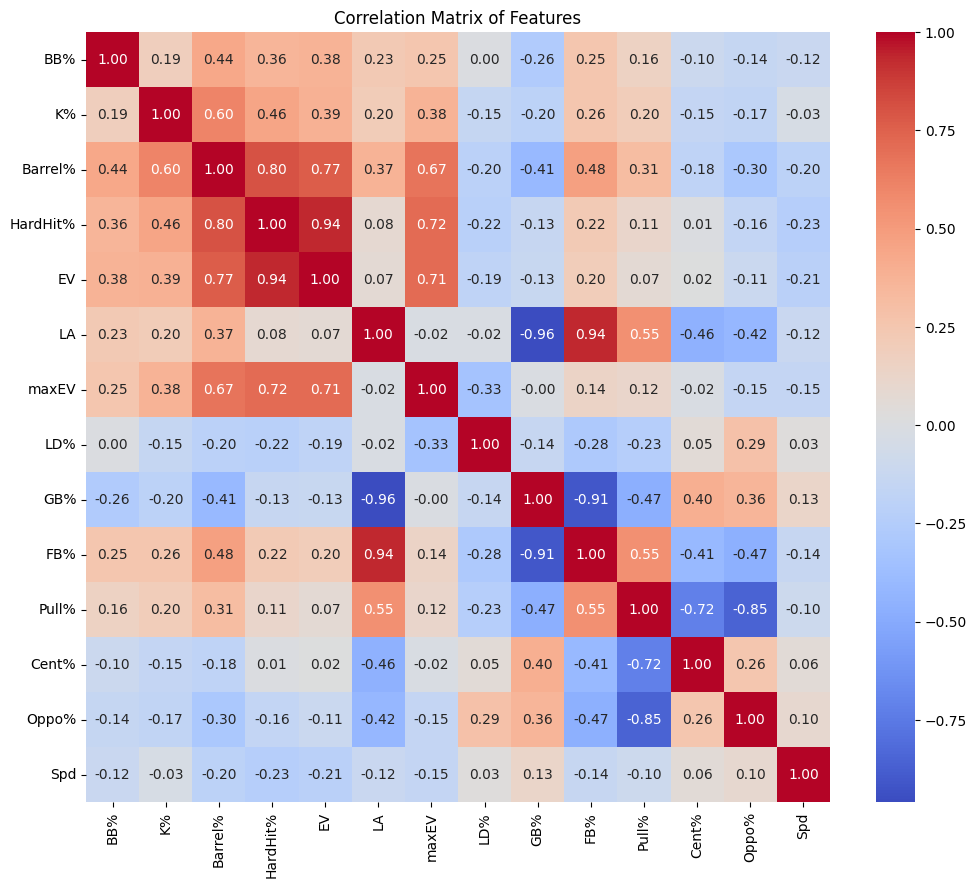

In [270]:
# correlation matrix 
plt.figure(figsize=(12, 10))
sns.heatmap(x.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.show()

### Initial Coefficient Analysis and Multicollinearity Detection

Before removing redundant features, I examined the learned coefficients from the baseline linear regression model to better understand feature influence.

The results supported the hypothesis of strong multicollinearity among several input variables. In particular, groups of features that represent compositional breakdowns of the same underlying behavior (e.g., batted ball distribution and spray direction) exhibited extremely large and unstable coefficient values.

These inflated coefficients indicate that the model is attempting to distribute the same underlying signal across multiple highly dependent variables, making interpretation unreliable.

Key examples include:

- Pull%, Cent%, and Oppo% (spray direction components)  
- GB%, LD%, and FB% (batted ball profile components)

Because these variables are mathematically constrained to sum to 100%, including all of them simultaneously introduces redundancy and instability in linear regression.

This analysis confirmed the need to remove or reduce correlated feature groups before proceeding with model refinement.

In [271]:
# print the coefficients of the linear regression model
coeffs = pd.Series(model.coef_, index=x.columns)
print(coeffs.sort_values(ascending=False).head(15))


LD%         5.606096e+07
FB%         5.606095e+07
GB%         5.606095e+07
Pull%       3.925068e+05
Oppo%       3.925055e+05
Cent%       3.925023e+05
Barrel%     2.323496e+01
BB%         1.282437e+01
HardHit%    2.631547e+00
Spd         5.399561e-01
EV          8.360277e-02
LA          1.057073e-02
maxEV      -9.013740e-03
K%         -1.843576e+01
dtype: float64


Below are the features removed based on high multicollinearity and low relative importance from the model coefficients.

In [272]:
# removing features with low importance and high correlation
x_reduced = x.drop(['Cent%', 'HardHit%', 'maxEV', 'FB%'], axis=1)

## Adding Positional Data

Positional information was incorporated to capture defensive and positional value, which is an important component of WAR.

The position dataset is stored in `MLB-Analytics/Data/Positions 15-25.csv` within this GitHub repository and is also sourced from FanGraphs.

This dataset is merged with the main player season data using the FanGraphs player ID to ensure accurate alignment across seasons.

For players with missing or unrecorded positions, the value is labeled as "Unknown" to maintain consistency prior to one-hot encoding.

In [273]:
# reading the positions data
positions = pd.read_csv('data/Positions 15-25.csv')
# keeping only the necessary columns from the positions dataframe
positions = positions[['Season', 'Pos', 'PlayerId']]

In [274]:
# merging the positions and main dataframes
df = pd.merge(df, positions, on=['PlayerId', 'Season'], how='left')

In [275]:
# change NAN positions to 'Unknown'
df['Pos'] = df['Pos'].fillna('Unknown')
# one hot encode positions
df = pd.get_dummies(df, columns=['Pos'], prefix='Pos')

In [276]:
y = df['WAR']
x = df.drop(['Season', 'PA', 'WAR', 'Name', 'Team', 'NameASCII', 'PlayerId', 'MLBAMID', 'Cent%', 'HardHit%', 'maxEV', 'FB%', 'BABIP'], axis=1)

## Updated Model: Adding Positional Features

To evaluate the impact of positional value on WAR prediction, the linear regression model is re-trained using the same feature set as the baseline model, with the addition of one-hot encoded positional variables.

This allows for a comparison between:

- A model using only offensive skill metrics  
- A model using both offensive metrics and positional context

The goal is to determine how much explanatory power is gained by including positional information, which is a key component of WAR.

In [277]:
# re-running the model with the reduced features
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
reduced_model = LinearRegression()
reduced_model.fit(x_train, y_train)
y_pred_reduced = reduced_model.predict(x_test)

### Reduced Model Results

After feature reduction and the addition of positional variables, the model performance improved significantly.

The R² increased to 0.61, indicating that the model now explains approximately 61% of the variance in WAR using offensive metrics and positional context.

The reduction in Mean Squared Error to 1.64 also suggests improved prediction accuracy on unseen data.

This improvement highlights the importance of positional value in WAR, which is not fully captured by offensive metrics alone.

In [278]:
mse_reduced = round(mean_squared_error(y_test, y_pred_reduced), 2)
print(f'Mean Squared Error (Reduced): {mse_reduced}')
r2_reduced = round(r2_score(y_test, y_pred_reduced), 2)
print(f'R^2 Score (Reduced): {r2_reduced}')

Mean Squared Error (Reduced): 1.64
R^2 Score (Reduced): 0.61


## Interpreting Model Coefficients

The updated model coefficients provide insight into which underlying player skills are most strongly associated with WAR.

Barrel% is the strongest predictor in the model, highlighting the importance of consistently producing high quality contact as a key driver of overall value. BB% also shows a strong positive relationship with WAR, reinforcing the importance of plate discipline and on base ability in player performance.

Line drive rate (LD%) contributes meaningfully as well, suggesting that consistently putting the ball in play at optimal angles remains an important component of offensive value. In contrast, exit velocity and launch angle have relatively small direct effects once quality of contact metrics are included, indicating that their signal is largely captured through Barrel% and related features.

Speed (Spd) provides a moderate positive contribution, showing that baserunning and athleticism still add measurable value but are secondary to offensive production.

Positional variables behave in a way that aligns well with how WAR is constructed. Premium defensive positions such as catcher, shortstop, and third base carry positive coefficients, while corner outfield positions are slightly negative, reflecting differences in positional scarcity and defensive responsibility.

Overall, the coefficient structure is consistent with modern baseball evaluation, where quality of contact, strike zone control, and positional context are the primary drivers of player value.

In [279]:
# printing the coefficients of the reduced model
coeffs_reduced = pd.Series(reduced_model.coef_, index=x.columns)
print(coeffs_reduced.sort_values(ascending=False).head(15))

Barrel%    26.598306
BB%        16.085149
LD%        10.168737
Pull%       4.373608
Oppo%       3.929844
Pos_C       0.867784
Pos_3B      0.748817
Pos_SS      0.601904
Spd         0.498170
Pos_2B      0.169574
EV          0.135740
Pos_CF      0.100772
LA         -0.007009
GB%        -0.196083
Pos_RF     -0.439805
dtype: float64


## Predicted vs Actual WAR

This scatter plot compares the models predicted WAR values against the actual observed WAR for each player season.

The diagonal line represents a perfect fit, where predicted values exactly match actual values. Points closer to this line indicate more accurate predictions, while larger deviations represent higher error.

This visualization provides a high level assessment of model performance and helps identify whether the model systematically over or under predicts player value across the full range of WAR.

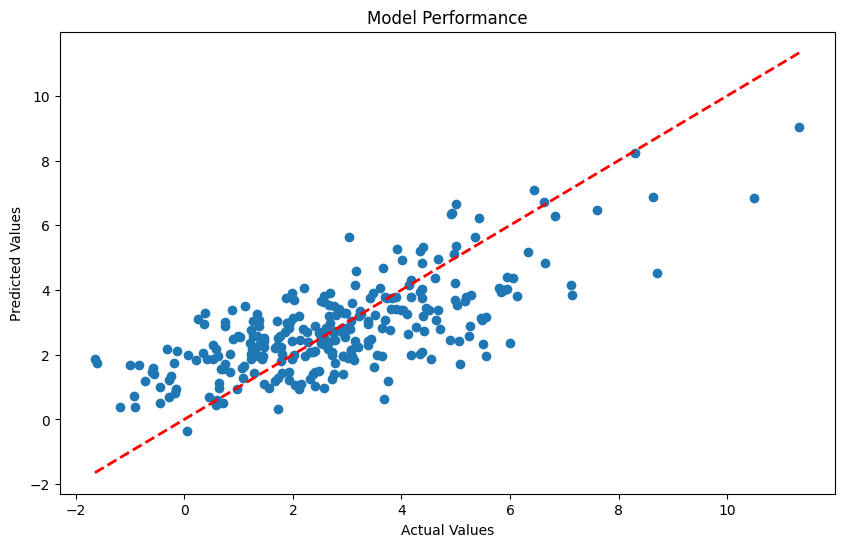

In [280]:
# plotting the predicitons vs actual values with trend line
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Model Performance')
plt.show()

The model shows a tendency to underpredict lower WAR players and slightly overpredict higher WAR players, suggesting a regression toward the mean.

Mid tier players are generally estimated with the highest accuracy, where predicted values closely align with actual WAR.

The largest deviations are concentrated among a small number of outlier seasons, particularly high impact MVP-level performances that the model does not fully capture.

## Residuals vs Actual WAR

This plot compares the model residuals (prediction errors) against the actual WAR values to evaluate whether errors are randomly distributed or exhibit systematic patterns.

In a well performing linear model, residuals should be centered around zero with no clear structure across the range of actual WAR values. This indicates that the model is not consistently overpredicting or underpredicting players at specific performance levels.

This visualization helps identify whether the model struggles more with high value players, replacement level players, or specific player archetypes.

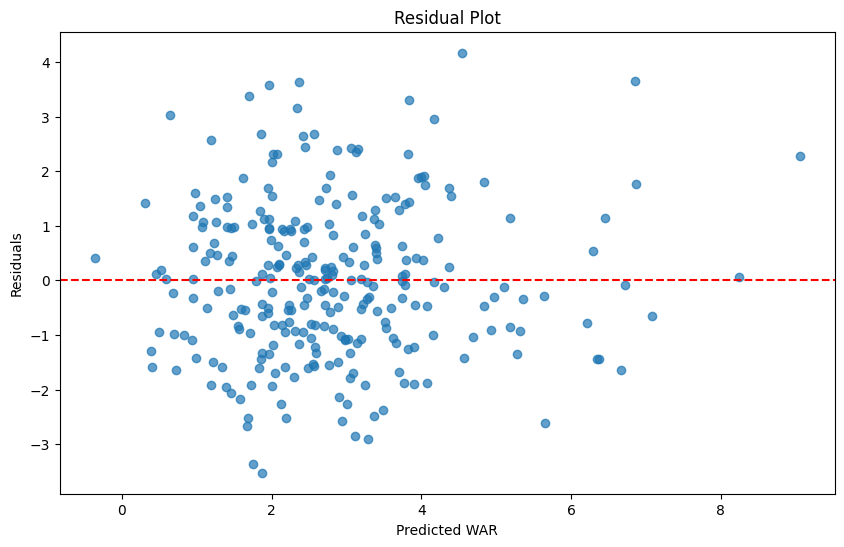

In [281]:
# residual plot
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted WAR')
plt.ylabel('Residuals')
plt.show()

## Generating WAR Predictions

After training and evaluating the model, predictions are generated for all player season observations in the dataset. This allows for a direct comparison between actual WAR values and model estimates at the individual player level.

Inspecting these predictions provides an initial sense of model performance beyond aggregate metrics, and helps identify how well the model captures variation across different types of players.

In [283]:
# using the linear model to predict WAR for each player in the dataset
df['Predicted_WAR'] = reduced_model.predict(x)
df[['Name', 'Season', 'WAR', 'Predicted_WAR']].head(20)

,Name,Season,WAR,Predicted_WAR
0,Oneil Cruz,2025,1.580288,5.664613
1,Giancarlo Stanton,2017,6.434607,3.918302
2,Giancarlo Stanton,2021,3.050541,2.276573
3,Giancarlo Stanton,2018,3.772407,2.730642
4,Oneil Cruz,2024,3.603457,5.457229
5,Ronald Acuña Jr.,2023,9.154090,8.536484
6,Aaron Judge,2017,8.695028,8.351730
7,Vladimir Guerrero Jr.,2025,3.887598,4.623402
8,Shohei Ohtani,2025,7.480309,8.159762
9,Manny Machado,2021,4.476650,6.734334


## Identifying Largest Prediction Errors

To better understand where the model performs well and where it struggles, prediction errors are calculated as the difference between actual WAR and predicted WAR.

Both signed error and absolute error are computed to capture:

- Directional bias (overprediction vs underprediction)  
- Magnitude of error regardless of direction  

The players with the largest absolute errors are then examined to identify potential model limitations and uncover player profiles that are not fully captured by the available features.

In [286]:
# identifying players with the largest prediction errors
df['Prediction_Error'] = df['WAR'] - df['Predicted_WAR']
df['Absolute_Error'] = df['Prediction_Error'].abs()
top_errors = df.sort_values('Absolute_Error', ascending=False).head(10)
print(top_errors[['Name', 'Season', 'WAR', 'Predicted_WAR', 'Prediction_Error']])

                  Name  Season       WAR  Predicted_WAR  Prediction_Error
1277      Alex Bregman    2019  8.326162       4.173807          4.152355
0           Oneil Cruz    2025  1.580288       5.664613         -4.084325
208      Marcell Ozuna    2017  5.551123       1.609901          3.941222
948        Jeff McNeil    2022  5.508084       1.622110          3.885974
356      Robinson Canó    2016  6.392560       2.528715          3.863845
109       Bryce Harper    2015  9.315671       5.461856          3.853815
558        Trea Turner    2021  7.121144       3.326849          3.794295
473        Kris Bryant    2016  7.521381       3.751197          3.770184
538   Paul Goldschmidt    2022  6.835823       3.071830          3.763993
933       Keibert Ruiz    2023 -0.544270       3.101466         -3.645736


## Interpreting Largest Prediction Errors

The largest prediction errors highlight specific seasons where the model struggles to accurately estimate WAR, particularly at the extremes of player performance.

Several high WAR seasons are consistently underpredicted, including Alex Bregman (2019), Bryce Harper (2015), Trea Turner (2021), and Paul Goldschmidt (2022). In these cases, actual WAR significantly exceeds predicted values, suggesting that the model does not fully capture the total value contributed in elite seasons.

On the other side, players such as Oneil Cruz (2025) and Keibert Ruiz (2023) are strongly overpredicted, where the model assigns substantially higher WAR than what was actually produced.

Overall, the pattern suggests that the model performs most reliably in typical performance ranges, while both elite seasons and underperforming high upside players tend to produce the largest deviations from predicted WAR.

## Summary of Results

Overall, the linear regression model provides a reasonably strong approximation of WAR using a small set of underlying player skill and profile metrics. After feature selection and the inclusion of positional information, the model explains approximately 61% of the variation in WAR, indicating that a substantial portion of player value can be captured through measurable offensive traits and positional context alone.

The most important predictors of WAR in the model are quality of contact and plate discipline metrics. Barrel% is the strongest positive contributor, followed by BB%, highlighting the importance of generating high quality contact and maintaining strong strike zone control. Line drive rate (LD%) also contributes positively, while metrics such as exit velocity and launch angle play a smaller role once quality of contact variables are included.

Positional adjustments improve model performance and behave consistently with expectations. Premium defensive positions such as catcher, shortstop, and third base carry higher positive coefficients, while corner outfield positions tend to be negative, reflecting differences in positional scarcity and defensive responsibility.

The residual and outlier analysis highlights the main limitation of the model. It performs best for mid range player seasons but struggles with extreme outcomes. Elite MVP caliber seasons are often underpredicted, suggesting that total player value in these cases comes from multi dimensional contributions not fully captured by offensive profile metrics alone. Conversely, some high upside players are overestimated when underlying tools do not translate into realized production.

Overall, the project demonstrates that WAR can be meaningfully approximated using a compact set of skill based features, but also reinforces that full player value includes nonlinear interactions and defensive contributions that are not fully represented in the current model.